## Домашнее задание №4. Работа с NPV моделью

*Дата выдачи: 17.08.2026*

*Дедлайн: 24.08.2026 23:59*


### Задание 1: Написать расчет IRR
- Добавить метод для расчета IRR


### Задание 2: Исследовать NPV-модель на чувствительность 
- Меняем параметры вверх-вниз, считаем NPV для новых параметров
- Объясняем, как и почему изменился NPV


### Задание 3: добавить страховку в NPV модель
- Страховка стоит 0.5% от лимита
- Подключена у 40% клиентов в статусе CUR и у 60% в статусе DLQ
- Возможно наступление страхового случая с вероятностью 0.1%, при подключенной страховке мы должны возместить всю сумму текущей задолженности
- Нужно добавить страховку в модель и сделать выводы о том, как и почему меняется NPV

Вам нужно внести изменения в код ниже. Где – подсказывать не будем, это часть задания. Добавьте комментарий с указанием места, котороые вы поменяли.

### Класс модели

In [1]:
import numpy as np

class NPVModel:

    avg_missed_payments = 1.5
    recovery = 0.50
    dlq_penalty_amount = 500
    oper_costs = 100
    collection_costs = 600
    tax_rate = 0.25
    discounting_rate = 0.30
    eq_req = 0.125
    cost_of_funds = 0.16
    acquisition_cost = 1000
    insurance_rate = 0.005    # Добавила сюда константы для Задания 3
    cur_insur = 0.40
    dlq_insur = 0.60
    insurance_prob = 0.001

    def __init__(self):
        pass

    def model_balance_calculations(self, amount, rate, term):
        '''
        Расчет модельных баланса, выплаченных процентов, регулярного платежа
        :param amount: Сумма кредита
        :param rate: Ставка
        :param term: Срок
        :return:
        balance : np.array(101) : остаток тела долга по кредиту на каждый месяц
        interest : np.array(101) : выплата по процентам каждый месяц
        regular_payment : float : размер регулярного платежа
        '''

        regular_payment = round(amount * (rate / 12) *\
                                (1 + (rate / 12)) / (1 - ((1 + rate / 12) ** (-term))))
        # График баланса и процентов
        balance = np.zeros(101)
        interest = np.zeros(101)
        balance[0] = amount

        for i in range(1, term + 1):
            int_payment = balance[i - 1] * rate / 12
            debt_payment = regular_payment - int_payment
            balance[i] = max(0, round(balance[i - 1] - debt_payment))
            interest[i] = int_payment
        return balance, interest, regular_payment

    def distribution_calc(self, portfolio_distribution, pd=None, pa=None):
        '''
        Расчет распределения по статусам
        :param portfolio_distribution: график распределения по статусам
        :return:
        cur_dist : np.array(101) : доля клиентов в статусе CUR на каждый месяц
        dlq_dist : np.array(101) : доля клиентов в статусе DLQ на каждый месяц
        act_dist : np.array(101) : доля клиентов в статусе ACT на каждый месяц
        def_dist : np.array(101) : доля клиентов в статусе DEF на каждый месяц
        clo_dist : np.array(101) : доля клиентов в статусе CLO на каждый месяц
        '''
        
        cur_dist = portfolio_distribution['CUR']
        dlq_dist = portfolio_distribution['DLQ']
        act_dist = cur_dist + dlq_dist
        def_dist = portfolio_distribution['DEF'] 
        clo_dist = portfolio_distribution['CLO']


        return cur_dist, dlq_dist, act_dist, def_dist, clo_dist

    def cur_balance_calc(self, model_balance, cur_dist):
        '''
        Расчет модельного баланса в статусе CUR
        :param model_balance: плановый график баланса
        :param cur_dist: доля клиентов в статусе CUR на каждый месяц
        :return:
        principal_balance_cur : np.array(101) : principal balance в статусе CUR
        gross_balance_cur : np.array(101) : gross balance в статусе CUR
        '''
        principal_balance_cur = model_balance*cur_dist
        gross_balance_cur = model_balance*cur_dist
        return principal_balance_cur, gross_balance_cur

    def dlq_balance_calc(self, model_balance, regular_payment, dlq_dist):
        '''
        Расчет модельного баланса в статусе DLQ
        :param model_balance: плановый график баланса
        :param regular_payment: размер регулярного платежа
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :return:
        principal_balance_dlq : np.array(101) : principal balance в статусе DLQ
        gross_balance_dlq : np.array(101) : gross balance в статусе DLQ
        '''
        principal_balance_dlq = np.append(0, model_balance[:-1])*dlq_dist
        gross_balance_dlq = (model_balance + regular_payment*self.avg_missed_payments)*dlq_dist
        return principal_balance_dlq, gross_balance_dlq

    def act_balance_calc(self, principal_balance_cur, principal_balance_dlq, gross_balance_cur, gross_balance_dlq):
        '''
        Расчет модельного баланса в статусе ACT
        :param principal_balance_cur: principal balance в статусе CUR
        :param principal_balance_dlq: principal balance в статусе DLQ
        :param gross_balance_cur: principal balance в статусе CUR
        :param gross_balance_dlq: principal balance в статусе DLQ
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :return:
        principal_balance_act : np.array(101) : principal balance в статусе ACT
        gross_balance_act : np.array(101) : gross balance в статусе ACT
        '''
        principal_balance_act = principal_balance_cur + principal_balance_dlq
        gross_balance_act = gross_balance_cur + gross_balance_dlq
        return principal_balance_act, gross_balance_act

    def def_balance_calc(self, model_balance, regular_payment, def_dist):
        '''
        Расчет модельного баланса в статусе DEF
        :param model_balance: плановый график баланса
        :param regular_payment: размер регулярного платежа
        :param def_dist: доля клиентов в статусе DEF на каждый месяц
        :return:
        principal_balance_def : np.array(101) : principal balance в статусе DEF
        gross_balance_def : np.array(101) : gross balance в статусе DEF
        '''
        principal_balance_def = np.zeros(101)
        gross_balance_def = np.zeros(101)

        def_dist_change = def_dist[4:] - def_dist[3:-1]
        principal_balance_def[4:] = np.cumsum(model_balance[:-4] * def_dist_change)
        gross_balance_def[4:] = np.cumsum((model_balance[4:] + 4 * regular_payment) * def_dist_change)

        return principal_balance_def, gross_balance_def

    def profit_calc(self, principal_balance_act, principal_balance_def, term, rate, dlq_dist):
        '''

        :param principal_balance_act: principal balance в статусе ACT
        :param principal_balance_def: principal balance в статусе DEF
        :param term: срок кредита
        :param rate: тавка по кредиту
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :return:
        profit : np.array(101) : доход на каждый месяц
        '''
        interest_profit = principal_balance_act*rate/12
        penatly_profit = dlq_dist*self.dlq_penalty_amount

        new_def_balance = np.append(principal_balance_def[1:], 0) - principal_balance_def
        recovery_profit = new_def_balance*self.recovery

        profit = interest_profit + recovery_profit + penatly_profit
        profit[term+1:] = 0

        return profit

    def loss_calc(self, gross_balance_act, principal_balance_def, term, act_dist, dlq_dist, def_dist):
        '''

        :param gross_balance_act: gross balance в статусе ACT
        :param principal_balance_def: principal balance в статусе DEF
        :param term: срок кредита
        :param act_dist: доля клиентов в статусе ACT на каждый месяц
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :param def_dist: доля клиентов в статусе DEF на каждый месяц
        :return:
        loss : np.array(101) : лосс на каждый месяц
        '''
        oper_loss = np.append(act_dist[1:], 0)*self.oper_costs
        loan_loss =  principal_balance_def - np.append(0, principal_balance_def[:-1])
        collection_loss = (np.append(dlq_dist[1:], 0) + np.append(def_dist[1:], 0))*self.collection_costs

        prev_gross_balance_act = np.append(0, gross_balance_act[:-1])
        cost_of_funds_loss = prev_gross_balance_act*(1 - self.eq_req)*self.cost_of_funds/12

        loss = loan_loss + cost_of_funds_loss + oper_loss + collection_loss
        loss[term+1:] = 0

        return loss, loan_loss, cost_of_funds_loss, oper_loss, collection_loss

    def assets_liabilities_calc(self, gross_balance_act):
        '''

        :param gross_balance_act: gross balance в статусе ACT
        :return:
        assets : np.array(101) : активы в проекте
        eq_req_curve : np.array(101) : активы, обеспеченные капиталом
        fund_req_curve : np.array(101) : активы, обеспеченные фондами
        '''

        # assets
        assets = gross_balance_act

        #liabilities
        eq_req_curve = assets*self.eq_req
        fund_req_curve = assets*(1 - self.eq_req)

        return assets, eq_req_curve, fund_req_curve

    def niat_calc(self, profit, loss):
        '''
        Расчет NIAT
        :param profit: суммарный доход на каждый месяц
        :param loss: суммарный лосс на каждый месяц
        :return:
        nibt : np.array(101) : прибыль до налогообложения
        niat : np.array(101) : прибыль после налогообложения
        tax : np.array(101) : налог в каждом месяце
        '''

        nibt = profit - loss
        tax = nibt*self.tax_rate
        niat = nibt - tax

        return nibt, niat, tax

    def cashflow_calc(self, principal_balance_act, principal_balance_def, amount, profit,
                      cost_of_funds_loss, oper_costs, collection_costs, tax, niat, eq_req_curve, fund_req_curve):
        '''
        Расчет денежных потоков
        :param principal_balance_act: principal balance в статусе DEF
        :param principal_balance_def: principal balance в статусе DEF
        :param amount: срок кредита
        :param profit: доход на каждый месяц
        :param cost_of_funds_loss: лоссы на фондирование
        :param oper_costs: операционные расходы
        :param collection_costs: расходы на коллекшн
        :param tax: налог в каждом месяце
        :param niat: доход после налогообложения
        :param eq_req_curve: активы, обеспеченные капиталом
        :param fund_req_curve: активы, обеспеченные фондами
        :return:
        cf_to_client : np.array(101) : денежный поток к клиенту
        cf_to_shareholders : np.array(101) : денежный поток к акционерам
        cf_to_debtholders : np.array(101) : денежный поток к фондам
        cf_to_cost_and_tax : np.array(101) : денежный поток на косты и налоги
        '''
        # client
        delta_principal_balance_act = (np.append(0, principal_balance_act[:100]) - principal_balance_act)
        delta_principal_balance_def = (np.append(0, principal_balance_def[:100]) - principal_balance_def)
        repayments = delta_principal_balance_act - delta_principal_balance_def + profit
        cf_to_client = np.append(amount, -repayments[1:])

        # debtoholder
        fund_req_ch = fund_req_curve - np.append(fund_req_curve[0], fund_req_curve[:-1])
        fund_req_change = np.append(fund_req_curve[0], fund_req_ch[1:])
        cf_to_debtholders = cost_of_funds_loss - fund_req_change

        # shareholders
        eq_req_ch = eq_req_curve - np.append(eq_req_curve[0], eq_req_curve[:-1])
        cf_to_shareholders = niat - np.append(eq_req_curve[0], eq_req_ch[1:])

        # cost and tax
        cf_to_cost_and_tax = oper_costs + collection_costs + tax

        return cf_to_client, cf_to_shareholders, cf_to_debtholders, cf_to_cost_and_tax


    def irr_calc(self, cf_to_shareholders):          # вот тут я добавляю расчет IRR :)

        periods = np.arange(101) / 12.

        def npv_at_rate(r):
            disc_curve = 1 / (1 + r) ** periods
            pv = np.sum(disc_curve * cf_to_shareholders)
            return pv - self.acquisition_cost

        low, high = -0.99, 50.0
        npv_low, npv_high = npv_at_rate(low), npv_at_rate(high)

        if npv_low * npv_high > 0:
            return np.nan

        for i in range(200):
            mid = (low + high) / 2
            npv_mid = npv_at_rate(mid)
            if abs(npv_mid) < 1e-6:
                break
            if npv_at_rate(low) * npv_mid < 0:
                high = mid
            else:
                low = mid

        return mid
    

    def insurance(self, amount, principal_balance_cur, principal_balance_dlq, cur_dist, dlq_dist):     # Вот сюда добавляю новый метод по страховке (это к заданию 3)
    
        insured_client = cur_dist*self.cur_insur + dlq_dist*self.dlq_insur
        insurance_income = amount*self.insurance_rate*insured_client

        insured_balance = principal_balance_cur*self.cur_insur + principal_balance_dlq*self.dlq_insur
        insurance_pay = insured_balance*self.insurance_prob

        return insurance_income, insurance_pay
    


    def npv_calc(self, amount, rate, term, portfolio_distribution, with_insurance=True, pd=None, pa=None):  # Добавила флаг страховки (3 задание)
        '''
        Расчет NPV
        :param amount: сумма кредита
        :param rate: ставка по кредиту
        :param term: срок кредита
        :param portfolio_distribution: график распределения по статусам
        :param pd: вероятность дефолта к 12-ому месяцу
        :param pa: вероятность полного досрочного погашения к 6-ому месяцу
        :return: npv: чистая приведенная стоимость кредита
        '''

        # Считаем балансы
        model_balance, interest, regular_payment =  self.model_balance_calculations(amount, rate, term)

        # Считаем распределение
        cur_dist, dlq_dist, act_dist, def_dist, clo_dist = self.distribution_calc(portfolio_distribution)

        # Считаем балансы
        principal_balance_cur, gross_balance_cur = self.cur_balance_calc(model_balance, cur_dist)
        principal_balance_dlq, gross_balance_dlq = self.dlq_balance_calc(model_balance, regular_payment, dlq_dist)
        principal_balance_act, gross_balance_act = self.act_balance_calc(principal_balance_cur, principal_balance_dlq, gross_balance_cur, gross_balance_dlq)
        principal_balance_def, gross_balance_def = self.def_balance_calc(model_balance, regular_payment, def_dist)

        # Считаем профиты
        profit = self.profit_calc(principal_balance_act, principal_balance_def, term, rate, dlq_dist)
        loss, loan_loss, cost_of_funds_loss, oper_loss, collection_loss = self.loss_calc(gross_balance_act, principal_balance_def,
                                                                                                                  term, act_dist, dlq_dist, def_dist)

        # Здесь добавляю саму страховку (Это по заданию 3)
        if with_insurance:
            insurance_income, insurance_pay = self.insurance(amount, principal_balance_cur, principal_balance_dlq, cur_dist, dlq_dist)
            profit = profit + insurance_income
            profit[term+1:] = 0
            loss = loss + insurance_pay
            loss[term+1:] = 0

        nibt, niat, tax = self.niat_calc(profit, loss)

        # Считаем активы и денежные потоки
        assets, eq_req_curve, fund_req_curve = self.assets_liabilities_calc(gross_balance_act)
        cf_to_client, cf_to_shareholders, cf_to_debtholders, cf_to_cost_and_tax =\
            self.cashflow_calc(principal_balance_act, principal_balance_def, amount, profit, cost_of_funds_loss, oper_loss, collection_loss,
                               tax, niat, eq_req_curve, fund_req_curve)

        # Считаем NPV
        disc_curve = np.array([1 / ((1 + self.discounting_rate) ** (i / 12.)) for i in range(101)])
        pv = np.round(np.sum(disc_curve * cf_to_shareholders)).astype(int)
        npv = pv - self.acquisition_cost

        irr = self.irr_calc(cf_to_shareholders)

        return npv, irr             # и как рассчитается возвращаю IRR

Добавила метод IRR как ставку дисконтирования, при которой NPV денежного потока к акционерам, при учете acquisition_cost как оттока в 0-ой месяц, обращается в ноль. Рассчитываю IRR по той же формуле дисконтирования, что используется в функции npv_calc, эта формула: 1 / (1+r)^(i/12) Здесь годовая эффективная ставка, применяемая к месячным периодам через дробную степень. А ещё IRR в данном кейсе удобнее NPV, так как он даёт единую цифру доходности в %, не привязанную к конкретному значению ставки дисконтирования. Соответственно, можно сразу же сравнить разные кредитные продукты между собой (или с cost of funds/eq_req), не пересчитывая NPV каждый раз под новую ставку.

### Пример использования модели

In [2]:
cur_dist = np.zeros(101)
dlq_dist = np.zeros(101)
clo_dist = np.zeros(101)
def_dist = np.zeros(101)

dlq_dist[1:12] += 0.05

def_dist[6:] += 0.03
def_dist[9:] += 0.03

def_dist[12:] += dlq_dist[11]

clo_dist[3:] += 0.10
clo_dist[6:] += 0.10
clo_dist[12:] = 1 - def_dist[12]

cur_dist = 1 - def_dist - clo_dist - dlq_dist

portfolio_distribution = {
    'CUR' : cur_dist,
    'DLQ' : dlq_dist,
    'DEF' : def_dist,
    'CLO' : clo_dist
         }

In [3]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    'CUR': cur_dist,
    'DLQ': dlq_dist,
    'DEF': def_dist,
    'CLO': clo_dist
})

df = df.reset_index().rename(columns={'index': 'Номер выписки'})
df = df.melt(id_vars='Номер выписки', value_vars=['DEF', 'DLQ', 'CUR', 'CLO'], 
             var_name='Status', value_name='Доля')

fig = px.area(df, x='Номер выписки', y='Доля', color='Status', 
              title='Распределение статусов по номерам выписки',
              color_discrete_map={
                  'DEF': '#D62728',
                  'DLQ': '#FF7F0E',
                  'CUR': '#2CA02C',
                  'CLO': '#1F77B4',
              },
              category_orders={'Status': ['DEF', 'DLQ', 'CUR', 'CLO']}
             )

fig.update_layout(height=600)
fig.update_xaxes(range=[0, 15])

fig.show()

In [4]:
model = NPVModel()
model.npv_calc(amount=200000, term=12, rate=0.24, portfolio_distribution=portfolio_distribution)

(np.int64(1062), 0.4584603438703561)

### Задание 2. Здесь исследую NPV на чувствительность.

In [5]:
import pandas as pd

base_case = dict(amount=200000, term=12, rate=0.24)

def run(rate=base_case['rate'], term=base_case['term'], amount=base_case['amount'], **attr_overrides):
    m = NPVModel()
    for k, v in attr_overrides.items():
        setattr(m, k, v)
    npv, irr = m.npv_calc(amount=amount, term=term, rate=rate, portfolio_distribution=portfolio_distribution)
    return npv, irr

npv_base, irr_base = run()

sen_params = {
    'rate':   (0.24, 0.24*1.2, 0.24*0.8),
    'term':   (12, 15, 9),
    'amount': (200000, 240000, 160000),
}

const_params = {
    'discounting_rate':    0.30,
    'eq_req':              0.125,
    'cost_of_funds':       0.16,
    'recovery':            0.50,
    'dlq_penalty_amount':  500,
    'oper_costs':          100,
    'collection_costs':    600,
    'tax_rate':            0.25,
    'acquisition_cost':    1000,
    'avg_missed_payments': 1.5,
}

rows = [['base', 'base', None, npv_base, irr_base]]

for p, (base, up, down) in sen_params.items():
    for label, val in [('up', up), ('down', down)]:
        kwargs = dict(base_case)
        kwargs[p] = val
        npv, irr = run(**kwargs)
        rows.append([p, label, val, npv, irr])

for p, base in const_params.items():
    for label, mult in [('up', 1.2), ('down', 0.8)]:
        val = base * mult
        npv, irr = run(**{p: val})
        rows.append([p, label, val, npv, irr])

df = pd.DataFrame(rows, columns=['param', 'direction', 'new_value', 'npv', 'irr'])
df['delta_npv_vs_base'] = df['npv'] - npv_base
df['irr_pct'] = (df['irr'] * 100).round(2)
df

,param,direction,new_value,npv,irr,delta_npv_vs_base,irr_pct
0,base,base,NaN,1062.0,0.458460,0.0,45.85
1,rate,up,0.288,4418.0,1.098276,3356.0,109.83
2,rate,down,0.192,-2280.0,0.015097,-3342.0,1.51
3,term,up,15.000,867.0,0.413642,-195.0,41.36
4,term,down,9.000,1438.0,0.558866,376.0,55.89
5,amount,up,240000.000,1643.0,0.508473,581.0,50.85
6,amount,down,160000.000,480.0,0.386972,-582.0,38.70
7,discounting_rate,up,0.360,637.0,0.458460,-425.0,45.85
8,discounting_rate,down,0.240,1517.0,0.458460,455.0,45.85
9,eq_req,up,0.150,728.0,0.384671,-334.0,38.47


Как видно по таблице, сильнее всего на NPV влияет ставка по кредиту (rate) и ставка фондирования (cost of funds). Они по сути напрямую формируют доход и расход банка на весь баланс. И даже не такое большое изменение переворачивают знак NPV, рост ставки до 0.288 увеличивает NPV до 4418.0, а падение ставки до 0.192 снижает NPV до −2280.0, хотя разница между ростом и падением 9.6 п.п. Такой признак как долг, полученная банком после дефолта клиента благодаря коллекшну (recovery) тоже сильный. Так как чем больше банк возвращает после дефолта, тем меньше безвозвратных потерь он несет. Интересно и немного не интуитивно, что признак увеличение срока кредита (term), снижает NPV. Но это можно объяснить тем, что при высокой ставке дисконтирования (около 30 %) более поздние денежные потоки сильнее обесцениваются при приведении к сегодняшнему дню. Ещё признак доля баланса кредита, которая должна быть профинансирована собственным капиталом акционеров (eq_req) тоже двигает NPV (С 728.0 до 1395.0) и IRR (irr_pct = 38.47, а потом = 58.99). Интересно, что сумма кредита влияет на NPV достаточно сильно (примерно + 581.0), такое происходит потому, что страховая премия считается как % от лимита. То есть, чем больше лимит, тем больше премий собирает банк.

Более того, можно увидеть, что признак ставка доходности на капитал, под которую банк готов дисконтировать будущие денежные потоки, чтобы посчитать их сегодняшнюю ценность (discounting_rate) двигает NPV, но ничего не происходит с IRR, irr_pct везде = 45.85. Так происходит скорее потому, что IRR это внутреннее свойство самого денежного потока, а не функция от требуемой доходности. Если посмотреть на остальные, то большинство других издержек (dlq_penalty_amount, tax_rate, acquisition_cost и т.д.) влияют на NPV в меньшей степени, скорее умеренно, так как часть костов в модели фиксированная и не так сильно выделяется или концентрируется в зависимости от размера баланса.

### Задание 3. Добавляю страховку в NPV модель.

Я вынесла страховку в отдельный метод чисто ради удобства в def insurance, и добавила сразу в npv_calc, чтобы всё было в одном месте. Поэтому комментарии пишу в самом коде, чтоб можно было там по # и найти.

In [6]:
npv_no_insur, irr_no_insur = model.npv_calc(amount=200000, term=12, rate=0.24, portfolio_distribution=portfolio_distribution, with_insurance=False)
npv_insur, irr_insur = model.npv_calc(amount=200000, term=12, rate=0.24, portfolio_distribution=portfolio_distribution, with_insurance=True)

print(f"Без страховки NPV = {npv_no_insur}, IRR = {irr_no_insur*100:.2f} %")
print(f"Со страховкой NPV = {npv_insur}, IRR = {irr_insur*100:.2f} %")
print(f"Дельта NPV {npv_insur - npv_no_insur}")

Без страховки NPV = -1419, IRR = 10.72 %
Со страховкой NPV = 1062, IRR = 45.85 %
Дельта NPV 2481


Как видно, страховка дала кардинальное изменение. Она изменила знак NPV с отрицательного на положительный. Без неё проект уходит в минус, NPV = -1419, а требуемая доходность 30 %. В то время как со страховкой проект в плюсе, NPV = 1062 и ещё есть запас (IRR = 45.85 %). Такое сильной влияние страховки можно объяснить тем, что за весь срок кредита банк накапливает страховых премий гораздо больше, чем тратит на редкие случаи выплат, поэтому чистый эффект от страховки положительный. Можно сказать, что страховка в данном кейсе работает как дополнительный высокомаржинальный продукт для банка. Так как он берёт на себя достаточно редкий, но дорогой риск, когда происходит полное списание долга при страховом случае, а в обмен дает частую премию. Более того, причина может быть в асимметрии между вероятностью расхода на ожидаемые возмещения = 0.1 % в месяц и ставкой = 0.5 % в месяц от лимита (в месяц) с застрахованной доли клиентов. 

### Место для комментариев

Спасибо большое за приятную домашку! Под конец интенсива самое то! Хорошо смогла разобраться в том, как модель будет работать с новым условием, то есть страховкой, и без неё, как поменяется NPV! Хорошего дня ! :)

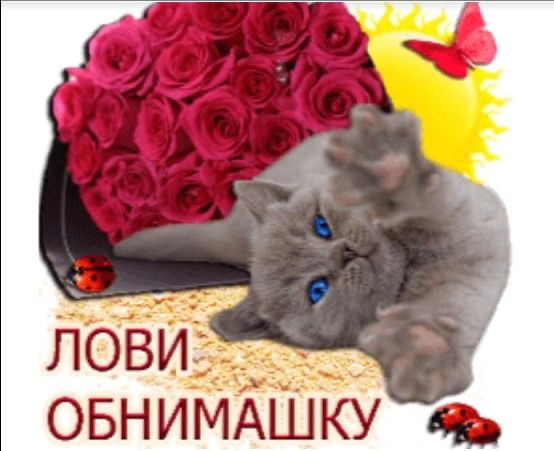